In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_ticket_price = pd.read_csv('multiplex_price_trends.csv')
df_ticket_price

,인상 시점,극장,주중 가격,주말 가격,비고
0,2009-06-26,메가박스,"8,000","9,000","주중, 주말 1,000원 인상"
1,2009-07-01,롯데시네마,"8,000","9,000",NaN
2,2009-07-03,CJ CGV,"8,000","9,000",NaN
3,2013-02-14,CJ CGV,"9,000","10,000",탄력요금제 도입
4,2013-07-19,메가박스,"9,000","10,000",탄력요금제 도입
5,2014-03-21,롯데시네마,"9,000","10,000",탄력요금제 도입
6,2016-03-03,CJ CGV,"10,000","11,000",좌석차등요금제 도입
7,2016-04-27,롯데시네마,"9,000","11,000",시간대별 차등요금제 도입
8,2016-07-04,메가박스,"9,000","11,000",차등요금제를 4단계에서 3단계로 조정
9,2018-04-11,CJ CGV,"11,000","12,000",NaN


In [3]:
year_ticket_price = df_ticket_price.groupby('인상 시점').max()
year_ticket_price.sort_values(by='인상 시점', ascending=True)

,극장,주중 가격,주말 가격,비고
인상 시점,,,,
2009-06-26,메가박스,"8,000","9,000","주중, 주말 1,000원 인상"
2009-07-01,롯데시네마,"8,000","9,000",NaN
2009-07-03,CJ CGV,"8,000","9,000",NaN
2013-02-14,CJ CGV,"9,000","10,000",탄력요금제 도입
2013-07-19,메가박스,"9,000","10,000",탄력요금제 도입
2014-03-21,롯데시네마,"9,000","10,000",탄력요금제 도입
2016-03-03,CJ CGV,"10,000","11,000",좌석차등요금제 도입
2016-04-27,롯데시네마,"9,000","11,000",시간대별 차등요금제 도입
2016-07-04,메가박스,"9,000","11,000",차등요금제를 4단계에서 3단계로 조정


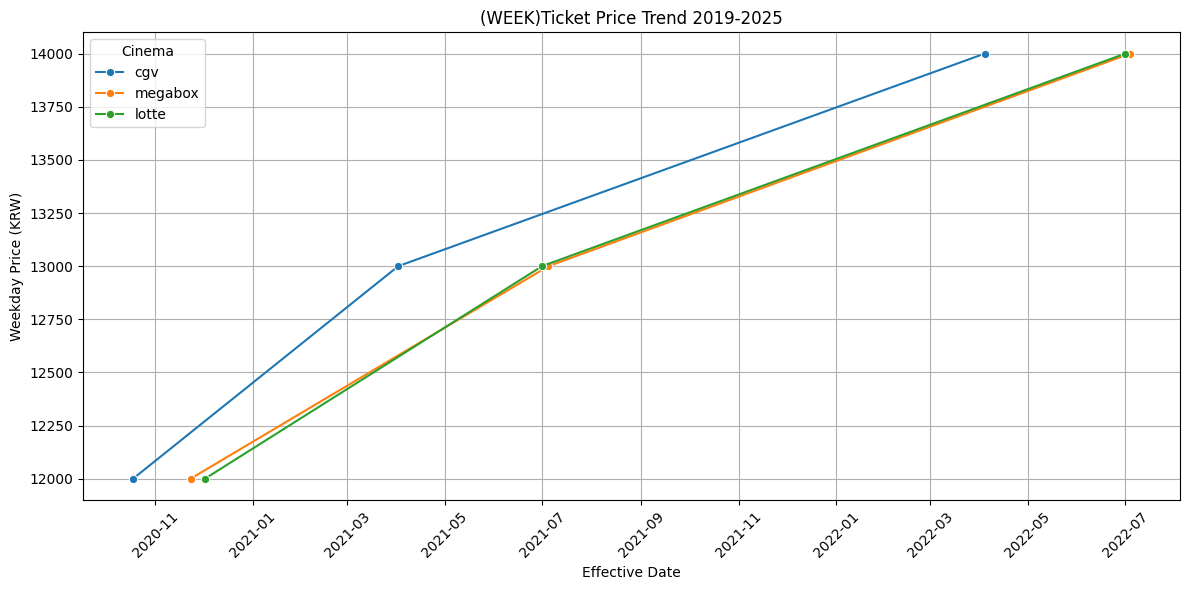

In [4]:
#전처리 (라벨링 포함)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = True
df_ticket_price['인상 시점'] = pd.to_datetime(df_ticket_price['인상 시점'])
df_filtered = df_ticket_price[(df_ticket_price['인상 시점'].dt.year >= 2019) & (df_ticket_price['인상 시점'].dt.year <= 2025)].copy()
df_filtered['주중 가격'] = df_filtered['주중 가격'].str.replace(',', '').astype(int)

df_filtered['극장'] = df_filtered['극장'].replace({
    'CJ CGV': 'cgv',
    '메가박스': 'megabox',
    '롯데시네마': 'lotte'
})

df_filtered.rename(columns={'인상 시점': 'Effective Date', '극장': 'Cinema', '주중 가격': 'Weekday Price'}, inplace=True)

#시각화
plt.figure(figsize=(12, 6))
year_of_ticket_price_week = sns.lineplot(
    x='Effective Date',
    y='Weekday Price',
    hue='Cinema',
    data=df_filtered,
    marker='o'
)

plt.title('(WEEK)Ticket Price Trend 2019-2025')
plt.xlabel('Effective Date')
plt.ylabel('Weekday Price (KRW)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()